# Overview

We consider the heart risk prediction problem based on the dataset:
https://www.kaggle.com/datasets/mahatiratusher/heart-disease-risk-prediction-dataset/data.

We cover the data analysis, preliminary modeling and performance evaluation of the preliminary model. Next, we consider several common classification models and analyse the performance.

# 1. Basic Steps

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.xls
/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv


In [2]:
# basic libs
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn libs for metric and reporting
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# for feature scaling
from sklearn.preprocessing import scale
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# ordinal and label encoding
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

# 2. Data

Load the diebeties dataset available at the location:

/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv'

Check first few rows.

In [3]:
df = pd.read_csv(r'/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv')

df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


**Basic data analysis**

There are 18 columns in the dataset. Name of target column is "Heart_Risk".
All the columns are as float64 type.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

**Check data distribution**

In [5]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


**Check feature data values**

The steps listed below will show that:
- All the columns expect Age exhibit binary values (0 or 1)
- Only the Age column has continuous integer values
- target column "Heart_Risk" is balanced




In [6]:
col_name = df.columns
print("--------- feature columns -----------")
print(col_name)
print("--------- feature column values ------")
for col in col_name:
    print("column: ", col, df[col].value_counts())

--------- feature columns -----------
Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')
--------- feature column values ------
column:  Chest_Pain Chest_Pain
0.0    35054
1.0    34946
Name: count, dtype: int64
column:  Shortness_of_Breath Shortness_of_Breath
1.0    35041
0.0    34959
Name: count, dtype: int64
column:  Fatigue Fatigue
0.0    35100
1.0    34900
Name: count, dtype: int64
column:  Palpitations Palpitations
0.0    35089
1.0    34911
Name: count, dtype: int64
column:  Dizziness Dizziness
1.0    35099
0.0    34901
Name: count, dtype: int64
column:  Swelling Swelling
0.0    35075
1.0    34925
Name: count, dtype: int64
column:  Pain_Arms_Jaw_Back Pain_Arms_Jaw_Back
1.0    35105
0.0    34

# 3. Baseline Model
Begin with the preliminary modelling. Try the basic models first.

Accuracy of Logistic Regression model: 0.99
Precision of Logistic Regression model: 0.99
Recall of Logistic Regression model: 0.99
F1 score of Logistic Regression model: 0.99


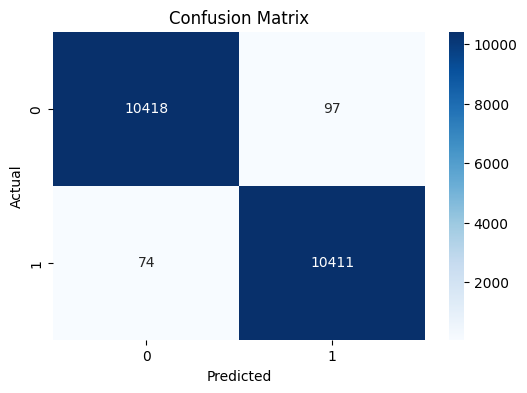

Miss classification error:
label 0 classifed as label 1 :  0.922491678554446
label 1 classifed as label 0 :  0.7057701478302336


In [7]:
# Create baseline for this classification problem
# consider logistic regression as baseline
# also use feature scaling for the Age column

# Prepare the dataset for modeling. Drop columns that are non-numeric and not needed for modelling
X = df.drop('Heart_Risk', axis=1)
y = df['Heart_Risk']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling for better performance of the logistic regression
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# Instantiate and train the logistic regression model
# model = LogisticRegression(max_iter=5000)
# model.fit(X_train_scaled, y_train)
# Make predictions and evaluate the model
# y_pred = model.predict(X_test_scaled)

# Instantiate and train the logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
# Make predictions and evaluate the model
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy of Logistic Regression model: {acc:.2f}')
print(f'Precision of Logistic Regression model: {prec:.2f}')
print(f'Recall of Logistic Regression model: {recall:.2f}')
print(f'F1 score of Logistic Regression model: {f1:.2f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Miss classification error:")
print("label 0 classifed as label 1 : ", cm[0][1] * 100 / (cm[0][0] + cm[0][1]))
print("label 1 classifed as label 0 : ", cm[1][0] * 100 / (cm[1][0] + cm[1][1]))

**Baseline results**

- accuracy of Logistic Regression model is more than 99 pcercent.
- precision, recall and F1 scores are are also more than 99 percent
- miss classification is quite low, less than 1 percent for the positive/negative cases

# 4. Model Training and Performance Evaluation
Logistic Regression established a reasonable baseline for the classification problem. Performance analysis in terms of accuracy, precision, recall, and f1 score indicate good baseline performance, with less than 1 percent of miss-classification error.

Now, we train several other classification models available, and evaluate performance of the trained models. Specifically, we are interested in the models which perform better w.r.t. baseline Logistic Regression model.

In [8]:
# create a method to predict and record the performance metrics
def predict(model_str, model, x_test, y_test):    
    model=model
    y_pred = model.predict(x_test)    
    print("confusion matrix: ", model)
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    FPPerc = cm[0][1] * 100 / (cm[0][0] + cm[0][1])
    TNPerc = cm[1][0] * 100 / (cm[1][0] + cm[1][1])    

    accu = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return ({"model":model_str, "accuracy":accu, "precision":prec, 
             "recall":recall, "f1_score":f1}, 
            {"model":model_str,"FN":cm[0][0],"FP":cm[0][1],
             "TN":cm[1][0],"TP":cm[1][1], 
             "FPPerc":FPPerc,
             "TNPerc":TNPerc
            })

In [9]:
# create a function to train and predict the models
def model_train_test_0(res, conf_mat, x_train, y_train, x_test, y_test):

    # train and test our favorite classifiers
    lr = LogisticRegression(solver='lbfgs', max_iter=5000)
    lr.fit(x_train, y_train)
    score, cm = predict("LR", lr, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)    
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    

    dt = DecisionTreeClassifier()
    dt.fit(x_train, y_train)
    score, cm = predict("DT", dt, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    

    return (res, conf_mat)

In [10]:
# create a function to train and predict the models
def model_train_test(res, conf_mat, x_train, y_train, x_test, y_test):

    # train and test our favorite classifiers
    lr = LogisticRegression(solver='lbfgs', max_iter=5000)
    lr.fit(x_train, y_train)
    score, cm = predict("LR", lr, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)        
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)

    # decision tree
    dt = DecisionTreeClassifier()
    dt.fit(x_train, y_train)
    score, cm = predict("DT", dt, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)    
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)

    # random forest
    rf = RandomForestClassifier()
    rf.fit(x_train, y_train)
    score, cm = predict("RF", rf, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)

    # XG Boost classifier
    xgb = XGBClassifier()
    xgb.fit(x_train, y_train)
    score, cm = predict("XGB", xgb, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)

    # Ada Boost classifier
    abc = AdaBoostClassifier()
    abc.fit(x_train, y_train)
    score, cm = predict("ABC", abc, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)
        
    # Gradient Boosting classifier
    gbc = GradientBoostingClassifier()            
    gbc.fit(x_train, y_train)
    score, cm = predict("GBC", gbc, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)

    # Extra Trees classifier
    etc = ExtraTreesClassifier()
    etc.fit(x_train, y_train)
    score, cm = predict("ETC", etc, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    

    svc = SVC()
    svc.fit(x_train, y_train)
    score, cm = predict("SVC", svc, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)    
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    
    
    
    lgbc = LGBMClassifier(verbose=-100)    
    lgbc.fit(x_train, y_train)
    score, cm = predict("LGBC", lgbc, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    

    knn = KNeighborsClassifier()
    knn.fit(x_train, y_train)
    score, cm = predict("KNN", knn, x_test, y_test)
    res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
    conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)    
    
    return (res, conf_mat)   

In [11]:
# prepare feature set and target set
# prepare target set
# train test split

x = df.drop(columns=['Heart_Risk'], axis=1)
y = df['Heart_Risk']

print(x.shape)
print(y.shape)

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.3)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

print("target class distribution : y_train")
print(y_train.value_counts())
print("target class distribution : y_test")
print(y_test.value_counts())

(70000, 18)
(70000,)
(49000, 18)
(49000,)
(21000, 18)
(21000,)
target class distribution : y_train
Heart_Risk
1.0    24515
0.0    24485
Name: count, dtype: int64
target class distribution : y_test
Heart_Risk
0.0    10515
1.0    10485
Name: count, dtype: int64


confusion matrix:  LogisticRegression(max_iter=5000)
[[10418    97]
 [   74 10411]]
confusion matrix:  DecisionTreeClassifier()
[[10321   194]
 [  193 10292]]


<ipython-input-10-978e8f29adc3>:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  res = pd.concat([res, pd.DataFrame([score])], ignore_index=True)
<ipython-input-10-978e8f29adc3>:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  conf_mat = pd.concat([conf_mat, pd.DataFrame([cm])], ignore_index=True)


confusion matrix:  RandomForestClassifier()
[[10427    88]
 [   75 10410]]
confusion matrix:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)
[[10420    95]
 [   75 10410]]
confusion matrix:  AdaBoostClassifier()
[[10436    79]
 [   52 10433]]
confusion matrix:  GradientBoostingClassifier(

<Axes: title={'center': 'Classification Error'}, xlabel='model'>

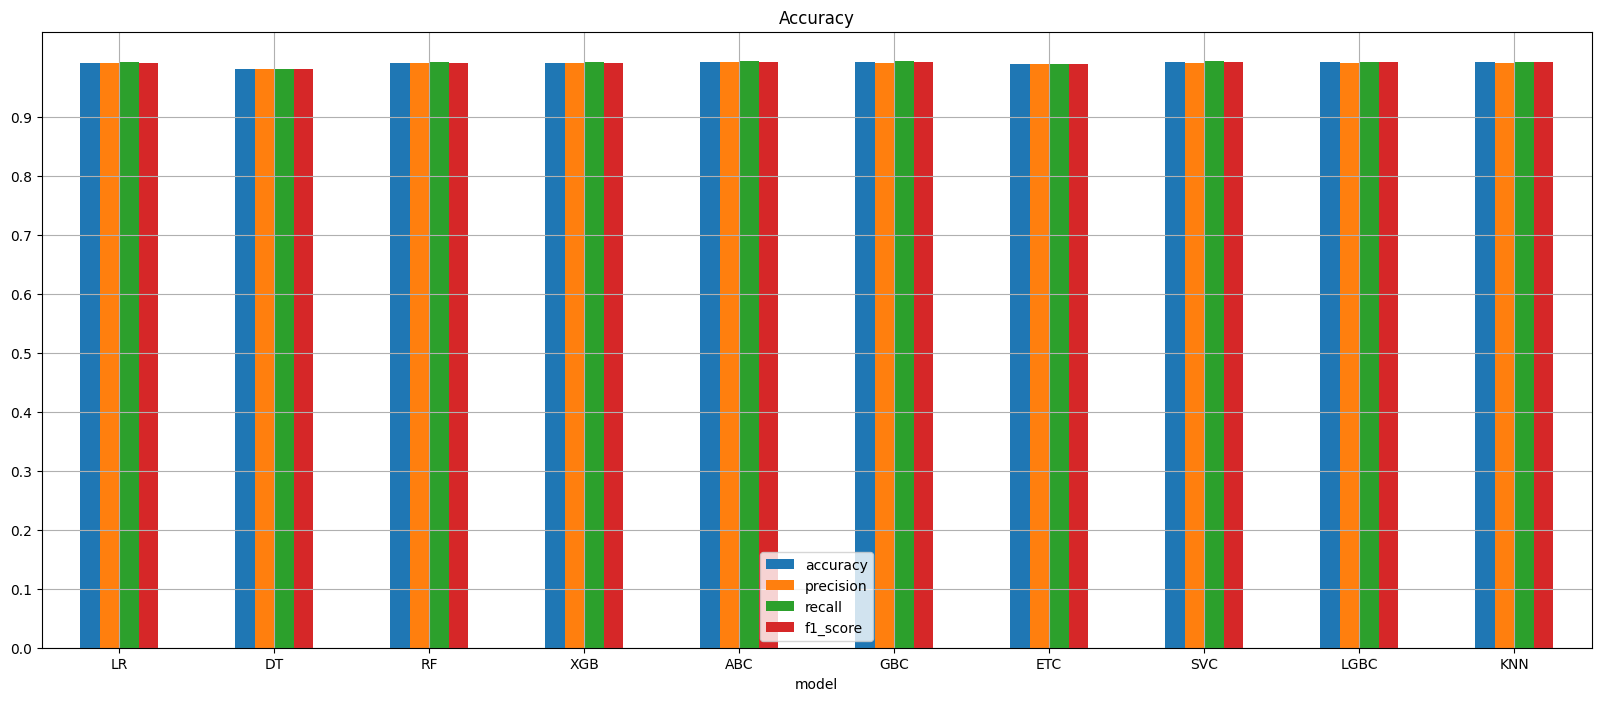

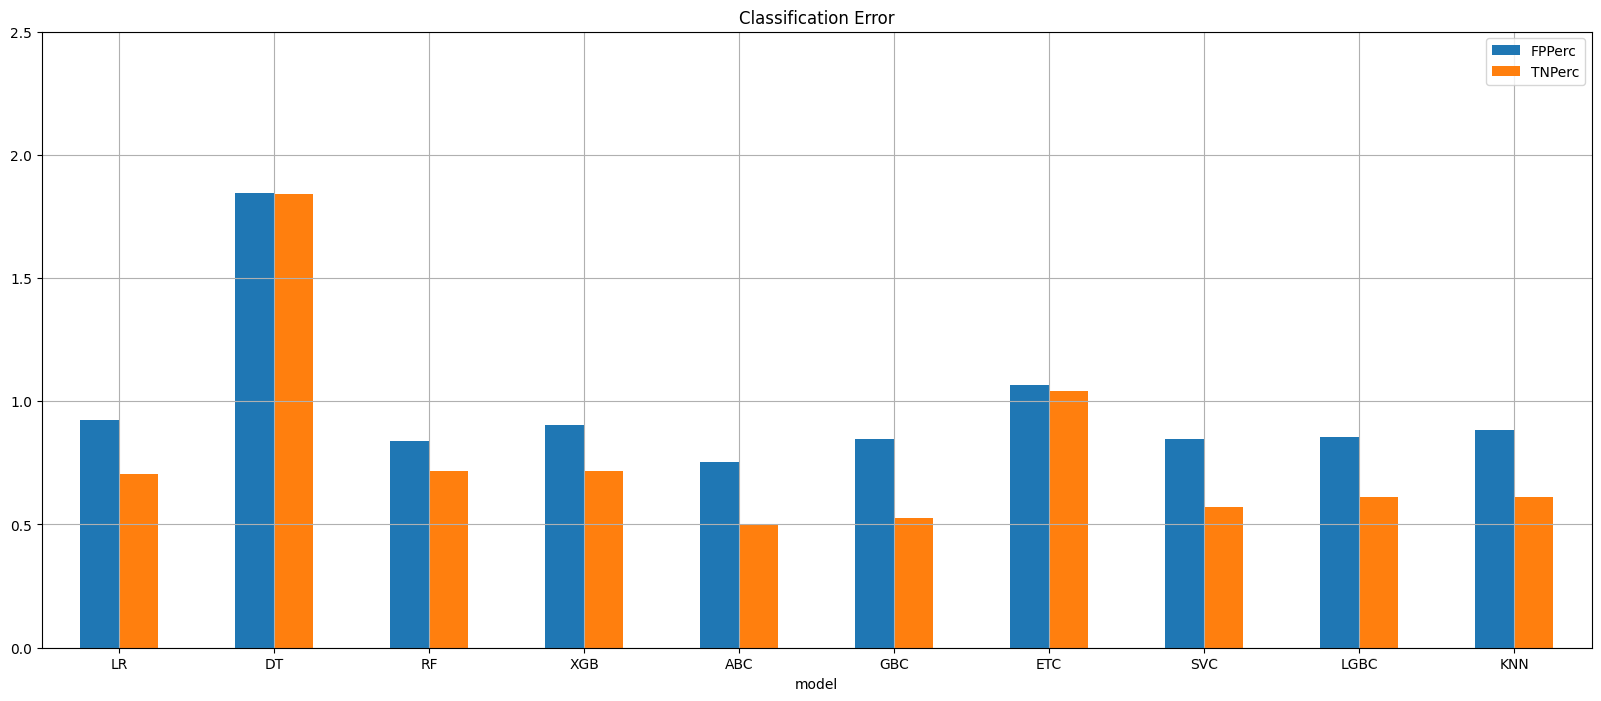

In [12]:
# create an empty df to record perf metrics
res = pd.DataFrame(columns=('model', 'accuracy', 'precision', 'recall', 'f1_score'))
cm = pd.DataFrame(columns=('model', 'FN', 'FP', 'TN', 'TP', 'FPPerc', 'TNPerc'))

# train and test
res, cm = model_train_test(res, cm, x_train, y_train, x_test, y_test)
print(res)
# plot performance metrics
res.plot(kind="bar", title='Accuracy', x='model', figsize=(20,8), yticks=np.arange(0, 1.0, 0.1), grid=True, rot=0.3)

# plot confusion matrics
print(cm)

cm.plot(kind="bar", title='Classification Error', x='model', y=['FPPerc','TNPerc'], 
        figsize=(20,8), yticks=np.arange(0, 3, 0.5), 
        grid=True, rot=0.3)

# 5. Conclusion and next steps

Evalaution of the models reveal that:

- baseline Logistic Regression model gives us 99.18 percent accuracy, recall and f1 score
- however, ensemble and gradient boosting models may outperform baseline LR model
- Ada boost and gradient boosting (ABC, GBC) have accuracy and f1 scores of 99.35 percent
- classification errors are also quite low with ABC, GBC; around 0.50 percent

As next steps:
- we can explore if models not considered in this work can improve the performance
- use techniques such as PCA to reduce data dimensionality
- may consider using data scaling techniques to standardize the Age column data.

